<a href="https://colab.research.google.com/github/ramasamybenazir-deep/Social-Media-Engagement-Analytics/blob/main/Social_Media_Engagement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [18]:
df = pd.read_csv("social_media_engagement_5000.csv")
print(df.columns.tolist())
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())

df.head()
df.tail()
df.shape
df.columns
df.info()
df.dtypes

['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   po

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [22]:
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')

In [23]:
df.isnull().sum()
df.isna().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [25]:
df.duplicated().sum()
df = df.drop_duplicates()

In [30]:
numeric_cols = ['likes', 'comments', 'shares', 'watch_time_sec','engagement_rate', 'follower_count']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


In [32]:
categorical_cols = ['gender', 'post_type', 'post_category', 'sentiment']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [33]:
df.head()
df.tail()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.info()
df.dtypes

df.describe()

Shape: (5000, 19)
Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares      

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348
std,26090.370121,14.912381,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029


In [35]:
df['post_type'].value_counts()
df['post_category'].value_counts()
df['sentiment'].value_counts()

df['post_type'].unique()
df['post_type'].nunique()

4

In [36]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
user_id,1.000000,-0.006789,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282
age,-0.006789,1.000000,-0.013353,-0.036767,-0.007369,0.014120,0.005677,0.013513,-0.025416,0.008044
post_id,0.020051,-0.013353,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139
likes,0.025811,-0.036767,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520
comments,-0.033395,-0.007369,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051
shares,0.013763,0.014120,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724
watch_time_sec,-0.016847,0.005677,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148
impression_count,0.015326,0.013513,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226
follower_count,0.010124,-0.025416,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292
engagement_rate,-0.004282,0.008044,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000


In [37]:
df['engagement_score'] = (
    df['likes'] +
    df['comments'] +
    df['shares']
)

In [38]:
df['hashtag_count'] = df['hashtags'].fillna('').apply(
    lambda x: len(str(x).split())
)

In [39]:
df.groupby('post_type')['likes'].mean().sort_values(ascending=False)

,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


In [44]:
df.groupby('country')['engagement_rate'].mean().sort_values(
    ascending=False
)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


In [45]:
df[numeric_cols].mean()

,0
likes,10106.997400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [46]:
df[numeric_cols].median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [47]:
df[numeric_cols].mode().iloc[0]

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


In [48]:
df[numeric_cols].std()

,0
likes,5702.293017
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [49]:
df[numeric_cols].var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [50]:
df[numeric_cols].quantile([0.25, 0.50, 0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [51]:
df[numeric_cols].skew()

,0
likes,-0.006894
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [52]:
df[numeric_cols].kurtosis()

,0
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


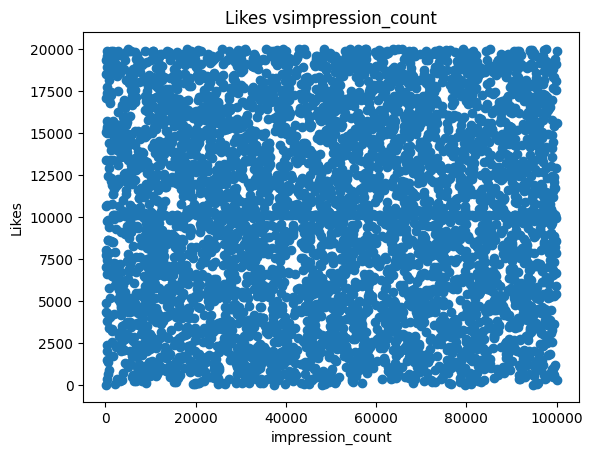

In [54]:
plt.scatter(df['impression_count'], df['likes'])
plt.xlabel('impression_count')
plt.ylabel('Likes')
plt.title('Likes vsimpression_count')
plt.show()

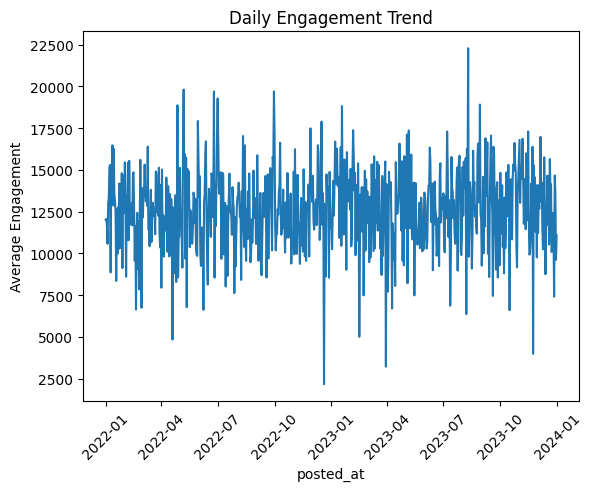

In [55]:
daily = df.groupby('posted_at')['engagement_score'].mean()

plt.plot(daily.index, daily.values)
plt.xlabel('posted_at')
plt.ylabel('Average Engagement')
plt.title('Daily Engagement Trend')
plt.xticks(rotation=45)
plt.show()

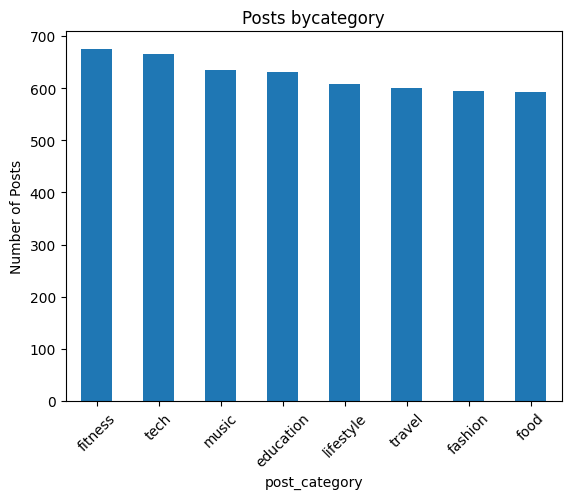

In [59]:
df['post_category'].value_counts().plot(kind='bar')

plt.xlabel('post_category')
plt.ylabel('Number of Posts')
plt.title('Posts bycategory')
plt.xticks(rotation=45)
plt.show()

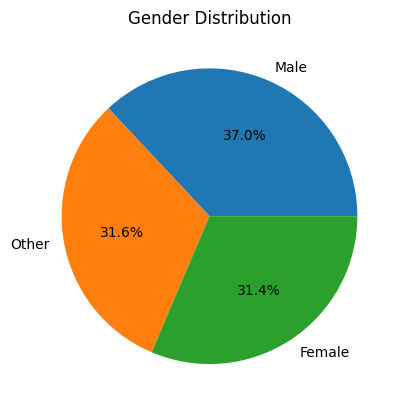

In [60]:
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

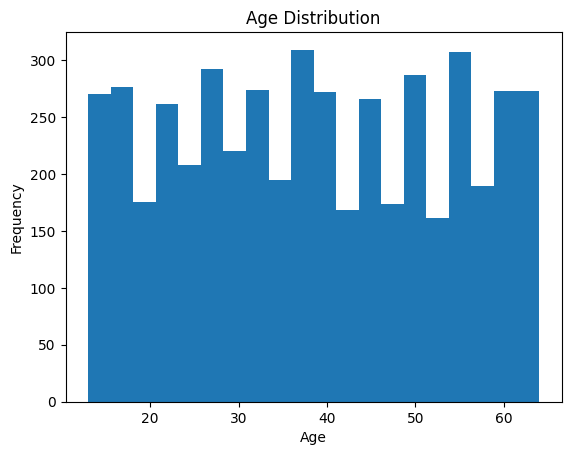

In [61]:
plt.hist(df['age'], bins=20)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

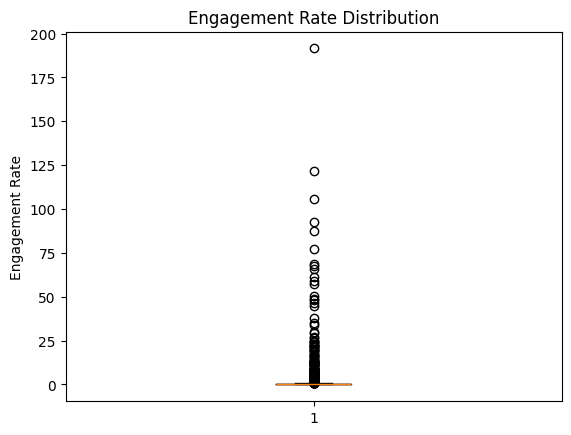

In [62]:
plt.boxplot(df['engagement_rate'].dropna())

plt.ylabel('Engagement Rate')
plt.title('Engagement Rate Distribution')
plt.show()

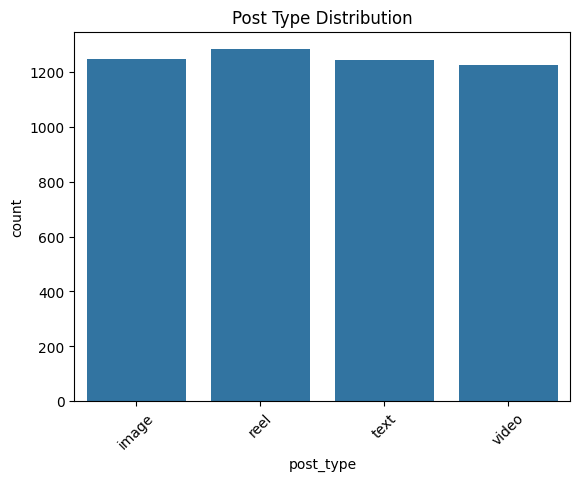

In [63]:
sns.countplot(data=df, x='post_type')

plt.title('Post Type Distribution')
plt.xticks(rotation=45)
plt.show()

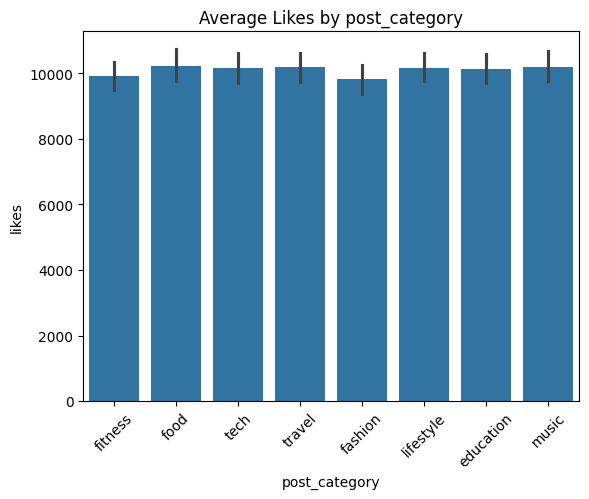

In [65]:
sns.barplot(
    data=df,
    x='post_category',
    y='likes'
)

plt.title('Average Likes by post_category')
plt.xticks(rotation=45)
plt.show()

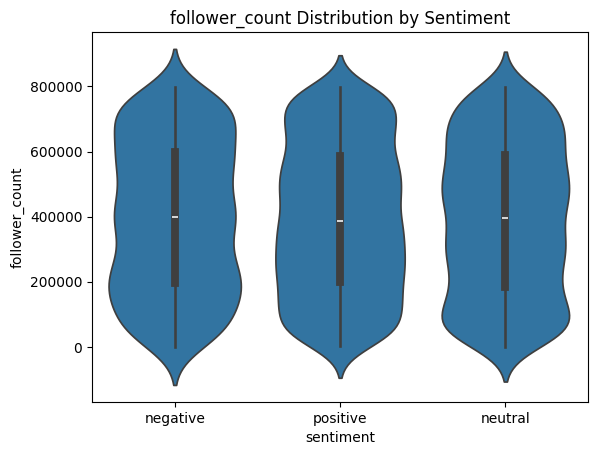

In [67]:
sns.violinplot(
    data=df,
    x='sentiment',
    y='follower_count'
)

plt.title('follower_count Distribution by Sentiment')
plt.show()

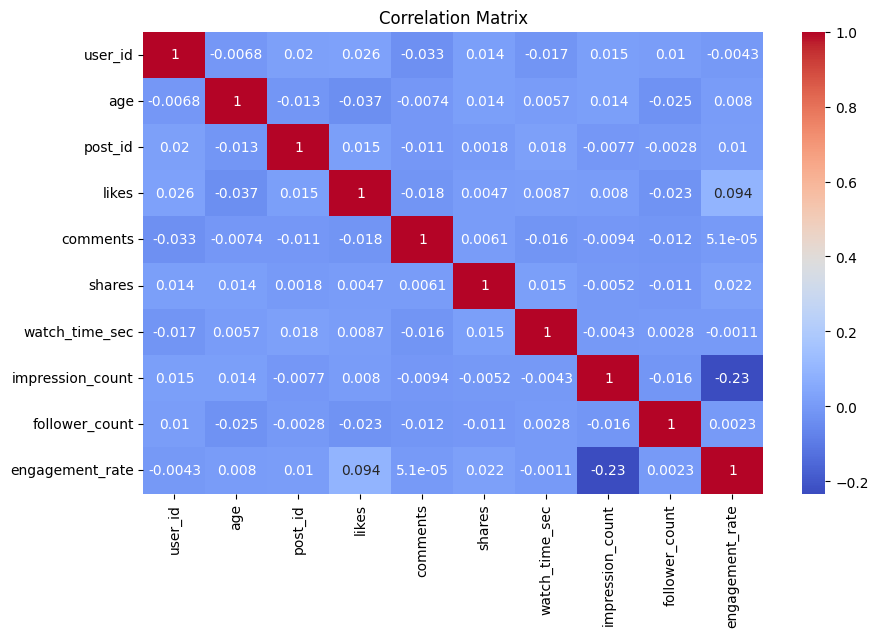

In [68]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [72]:
fig = px.line(
    df,
    x='posted_at',
    y='engagement_score',
    title='Interactive Daily Engagement Trend'
)

fig.show()
